<a href="https://colab.research.google.com/github/RizkyFirdiansyah/PCVK_Ganjil2026/blob/main/Week07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque
from scipy import ndimage as ndi
from skimage import data, filters, color, segmentation, feature, morphology
from skimage.filters import gaussian
from skimage.segmentation import flood

In [ ]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
  plt.figure(figsize=figsize)
  for i, (img, title) in enumerate(zip(images, titles)):
    ax = plt.subplot(1, len(images), i+1)
    if len(img.shape) == 2:
      plt.imshow(img, cmap='gray')
    else:
      plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))

    for spine in ax.spines.values():
      spine.set_visible(True)
      spine.set_color('black')
      spine.set_linewidth(0.5)

    ax.set_xticks([])
    ax.set_yticks([])
    plt.title(title)
  plt.show()

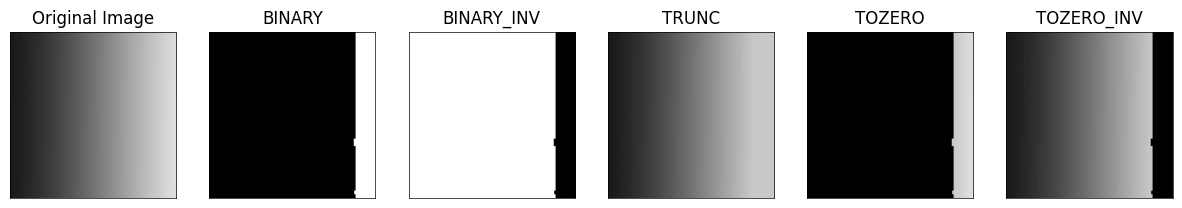

In [ ]:
# Global Threshold (binary, binary inverse, trunc, tozero, tozero inverse)
img = cv.imread('/content/drive/MyDrive/PCVK2026/gradient.jpg')
thresh = 200
maxval = 255

# Implementasi Manual
binary = np.where(img > thresh, maxval, 0).astype(np.uint8)
binary_inv = np.where(img <= thresh, maxval, 0).astype(np.uint8)
trunc = np.where(img > thresh, thresh, img).astype(np.uint8)
tozero = np.where(img > thresh, img, 0).astype(np.uint8)
tozero_inv = np.where(img <= thresh, img, 0).astype(np.uint8)

# Plotting
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, binary, binary_inv, trunc, tozero, tozero_inv]
show_side_by_side(images, titles)

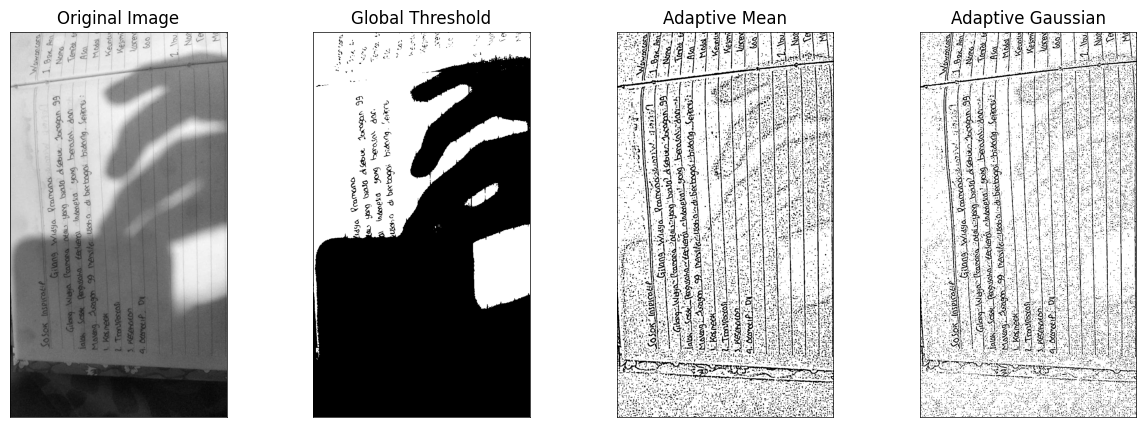

In [ ]:
# Addaptive Threshold (global threshold, adaptive mean, adaptive gaussian)
# Membuat kernel gaussian 2D secara manual
def get_gaussian_kernel(size, sigma):
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    return kernel / np.sum(kernel)

def adaptive_threshold_manual(image, window_size=11, C=2, method='mean', sigma=2):
    pad = window_size // 2
    # Padding
    padded_img = np.pad(image, pad, mode='reflect')
    out_img = np.zeros_like(image)

    if method == 'gaussian':
        kernel = get_gaussian_kernel(window_size, sigma)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            # Ambil tetangga sebesar 11x11
            window = padded_img[i:i+window_size, j:j+window_size]

            if method == 'mean':
                local_thresh = np.mean(window) - C
            else: # gaussian
                local_thresh = np.sum(window * kernel) - C

            out_img[i, j] = 255 if image[i, j] > local_thresh else 0

    return out_img

sudoku_img = cv.imread('/content/drive/MyDrive/PCVK2026/citraTidakMerata.jpeg', 0)
global_thresh = np.where(sudoku_img > 127, 255, 0).astype(np.uint8)
th_mean_manual = adaptive_threshold_manual(sudoku_img, 11, 2, 'mean')
th_gauss_manual = adaptive_threshold_manual(sudoku_img, 11, 2, 'gaussian', 2)

# Plotting
titles = ['Original Image', 'Global Threshold', 'Adaptive Mean', 'Adaptive Gaussian']
images = [sudoku_img, global_thresh, th_mean_manual, th_gauss_manual]
show_side_by_side(images, titles)

/tmp/ipykernel_2491/4001681248.py:19: RuntimeWarning: invalid value encountered in divide
  mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
/tmp/ipykernel_2491/4001681248.py:20: RuntimeWarning: invalid value encountered in divide
  muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)


Final Thresh : 126


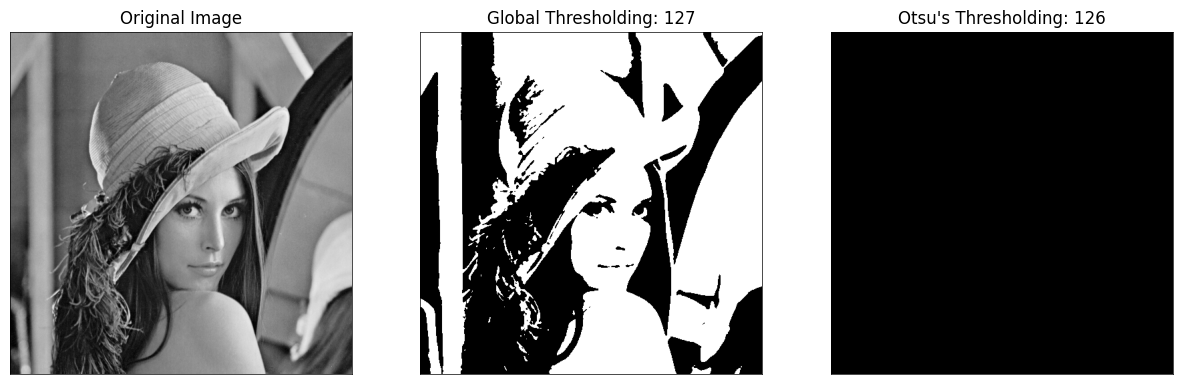

In [62]:
# Otsu Thresholding Manual
from typing_extensions import final
img = cv.imread('/content/drive/MyDrive/PCVK2026/Lenna.png', cv.IMREAD_GRAYSCALE)
blur = cv.GaussianBlur(img, (5,5),0)
thresh = 127

def otsu(gray):
  pixel_number = gray.shape[0] * gray.shape[1]
  mean_weight = 1.0/pixel_number
  his, bins = np.histogram(gray, np.arange(0,257))
  final_thresh = -1
  final_value = -1
  intensity_arr = np.arange(256)
  for t in bins[1:-1]:
    pcb = np.sum(his[:t])
    pcf = np.sum(his[t:])
    Wb = pcb * mean_weight
    Wf = pcf * mean_weight

    mub = np.sum(intensity_arr[:t] * his[:t]) / float(pcb)
    muf = np.sum(intensity_arr[t:] * his[t:]) / float(pcf)
    value = Wb * Wf * (mub - muf) ** 2

    if value > final_value:
      final_thresh = t
      final_value = value

  final_img = gray.copy()
  print(f'Final Thresh : ' + str(final_thresh))
  final_img[gray > final_thresh] = 255
  final_img[gray < 255] = 0
  return final_img, final_thresh

otsu_biner, otsu_thresh = otsu(blur)
x = ("Otsu's Thresholding: ") + str(otsu_thresh)
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)
titles = ['Original Image', 'Global Thresholding: ' + str(thresh), x]
images = [img, th1, otsu_biner]
show_side_by_side(images, titles)